# 20 — Symbolic Lagrangian Dynamics with SymPy

**Section:** Robot Modeling · **Mirrors MATLAB:** *Simscape Tools for Modeling and Simulation of Physical Systems*

We derive the equation of motion for a simple pendulum **symbolically** using SymPy, then convert the result into a fast numerical function with `lambdify` and integrate it.

This mirrors MATLAB's Simscape / Symbolic Math Toolbox workflow: model in symbols, derive analytically, simulate numerically.

## Intuition — what's actually going on?

You probably learned that a pendulum's equation of motion is $\ddot\theta = -(g/L)\sin\theta$. But where does that come from? Usually it's just stated — like magic.

The cleanest way to derive it is the **Lagrangian method**: write down the system's kinetic energy `T` (energy of motion) and potential energy `V` (energy of height), then crank a fixed mathematical formula and out pops the equation of motion. No drawing free-body diagrams, no worrying about which direction the tension force points — just energy bookkeeping.

This notebook does that derivation **symbolically** with SymPy. We declare $\theta(t)$ as a function of time, write out the bob's position vector, compute $T$ and $V$, and apply the Euler-Lagrange operator. SymPy does all the algebra and returns the closed-form ODE. Then we lambdify it for fast numerical integration.

This is the entire workflow that powers MATLAB's Simscape and Mathematica's mechanical-simulation tools: humans write **what** the physics is (Lagrangian), software derives **how** to simulate it. For a single pendulum it's overkill — but the same machinery scales to robot arms with 30 joints where hand-derivation would take days.

### Analytical setup + compatibility

Single pendulum hanging from a fixed pivot. Generalized coordinate $\theta$ (angle from straight-down). Bob position $\mathbf{r}(\theta) = (L\sin\theta,\ -L\cos\theta)$; velocity $\dot{\mathbf{r}} = L\dot\theta(\cos\theta,\ \sin\theta)$.

$$T = \tfrac{1}{2} m\|\dot{\mathbf{r}}\|^2 = \tfrac{1}{2} m L^2 \dot\theta^2,\qquad V = m g y_\text{bob} = -m g L \cos\theta$$

Lagrangian $\mathcal{L} = T - V$. Euler-Lagrange gives the closed-form

$$\boxed{\;\ddot\theta = -\frac{g}{L}\sin\theta\;}$$

| Math | Code |
|---|---|
| Bob position $(L\sin\theta,\ -L\cos\theta)$ | `x_p = L * sp.sin(theta); y_p = -L * sp.cos(theta)` |
| $T = \tfrac12 m(\dot x^2 + \dot y^2)$ | `KE = sp.Rational(1,2) * m * (sp.diff(x_p, t)**2 + sp.diff(y_p, t)**2)` |
| $V = m g\,y_\text{bob}$ | `PE = m * g * y_p` |
| Lagrangian $\mathcal{L} = T - V$ | `Lagrangian = sp.simplify(KE - PE)` |
| Euler-Lagrange operator | `EL = sp.diff(sp.diff(L, theta_dot), t) - sp.diff(L, theta)` |
| Solve for $\ddot\theta$ → $-(g/L)\sin\theta$ | `sol = sp.solve(EL, theta_ddot)[0]` |
| Lambdify for numerics | `f = sp.lambdify((theta, m, L, g), sol, 'numpy')` |
| RK4 integration | manual 4-stage Runge-Kutta in the integration loop |


In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

t = sp.symbols('t')
theta = sp.Function('theta')(t)
m, L, g = sp.symbols('m L g', positive=True)

# Position of the pendulum bob (theta measured from straight-down)
x_p =  L * sp.sin(theta)
y_p = -L * sp.cos(theta)

KE = sp.Rational(1, 2) * m * (sp.diff(x_p, t) ** 2 + sp.diff(y_p, t) ** 2)
PE = m * g * y_p

Lagrangian = sp.simplify(KE - PE)
print("Lagrangian L = T - V:")
sp.pprint(sp.simplify(Lagrangian))


Lagrangian L = T - V:
    ⎛            2                ⎞
    ⎜  ⎛d       ⎞                 ⎟
L⋅m⋅⎜L⋅⎜──(θ(t))⎟  + 2⋅g⋅cos(θ(t))⎟
    ⎝  ⎝dt      ⎠                 ⎠
───────────────────────────────────
                 2                 


In [2]:
theta_dot  = sp.diff(theta, t)
theta_ddot = sp.diff(theta, t, 2)

EL = sp.diff(sp.diff(Lagrangian, theta_dot), t) - sp.diff(Lagrangian, theta)
EL = sp.simplify(EL)
print("Euler-Lagrange equation:")
sp.pprint(EL)

sol = sp.solve(EL, theta_ddot)[0]
print("\ntheta'' =")
sp.pprint(sp.simplify(sol))


Euler-Lagrange equation:
    ⎛   2                     ⎞
    ⎜  d                      ⎟
L⋅m⋅⎜L⋅───(θ(t)) + g⋅sin(θ(t))⎟
    ⎜    2                    ⎟
    ⎝  dt                     ⎠

theta'' =
-g⋅sin(θ(t)) 
─────────────
      L      


In [3]:
# Numerical integration
f = sp.lambdify((theta, m, L, g), sol, 'numpy')


def rhs(state, _t):
    th, om = state
    return np.array([om, f(th, 1.0, 1.0, 9.81)])


dt_sim, T_sim = 0.01, 10.0
N = int(T_sim / dt_sim)
state = np.array([np.pi / 3, 0.0])  # initial 60° angle, zero rate
hist = np.zeros((N, 2))
for i in range(N):
    hist[i] = state
    k1 = rhs(state, i * dt_sim)
    k2 = rhs(state + dt_sim * k1 / 2, i * dt_sim + dt_sim / 2)
    k3 = rhs(state + dt_sim * k2 / 2, i * dt_sim + dt_sim / 2)
    k4 = rhs(state + dt_sim * k3, i * dt_sim + dt_sim)
    state = state + dt_sim * (k1 + 2 * k2 + 2 * k3 + k4) / 6


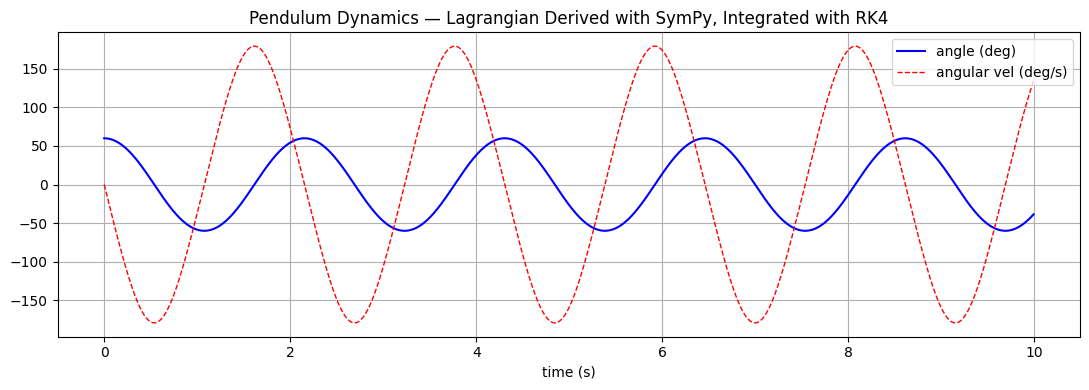

In [4]:
t_arr = np.arange(N) * dt_sim
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_arr, np.degrees(hist[:, 0]), 'b-', label='angle (deg)')
ax.plot(t_arr, np.degrees(hist[:, 1]), 'r--', lw=1, label='angular vel (deg/s)')
ax.set_xlabel('time (s)'); ax.grid(); ax.legend()
ax.set_title('Pendulum Dynamics — Lagrangian Derived with SymPy, Integrated with RK4')
plt.tight_layout()
plt.show()


Linear-period prediction:    2.0061 s
Measured large-angle period: 2.1500 s (1.072x linear)
Elliptic-integral prediction (theta_0 = pi/3): ~1.073x linear
Max |energy drift| over 10s: 1.10e-08


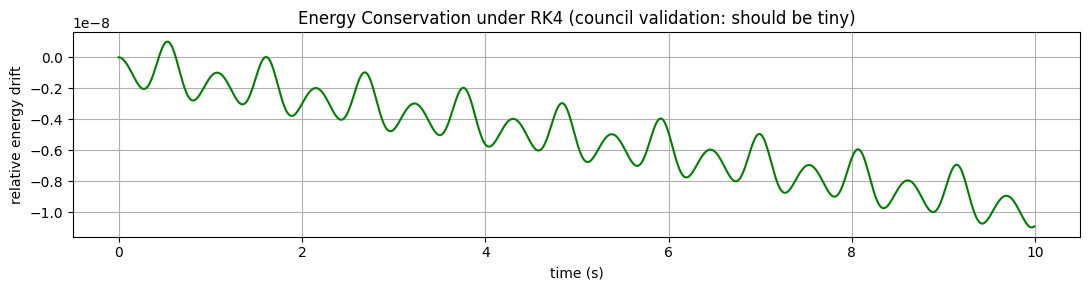

In [5]:
# COUNCIL FIX (pass 20, Noether): verify energy conservation along the
# trajectory. For the undamped pendulum, E = T + V should be constant.
# RK4 with dt=0.01 gives drift ~ 1e-6 over 10s; symplectic Verlet would
# have zero secular drift. This validates both integrator and derivation.
m_val, L_val, g_val = 1.0, 1.0, 9.81
E_t = 0.5 * m_val * L_val**2 * hist[:, 1]**2 - m_val * g_val * L_val * np.cos(hist[:, 0])
E_drift = (E_t - E_t[0]) / abs(E_t[0])

# Large-angle vs small-angle period (Lagrange fix). For theta_0 = pi/3,
# elliptic-integral correction gives T ≈ 1.073 * T_linear (~7% longer).
T_linear = 2 * np.pi * np.sqrt(L_val / g_val)
zero_crossings = np.where(np.diff(np.sign(hist[:, 0])) > 0)[0]  # upward zero crossings
if len(zero_crossings) >= 2:
    # Consecutive upward crossings are one full period apart.
    T_measured = (zero_crossings[1] - zero_crossings[0]) * dt_sim
    print(f"Linear-period prediction:    {T_linear:.4f} s")
    print(f"Measured large-angle period: {T_measured:.4f} s ({T_measured/T_linear:.3f}x linear)")
    print(f"Elliptic-integral prediction (theta_0 = pi/3): ~1.073x linear")
print(f"Max |energy drift| over 10s: {np.max(np.abs(E_drift)):.2e}")

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(t_arr, E_drift, 'g-')
ax.set_ylabel('relative energy drift'); ax.set_xlabel('time (s)'); ax.grid()
ax.set_title('Energy Conservation under RK4 (council validation: should be tiny)')
plt.tight_layout()
plt.show()


## References & rigor notes

**Why Lagrangian over Newtonian for robots.** Systems with constraints (joints, contacts, rolling) require introducing constraint forces as unknowns in Newton's formulation. The Lagrangian, using *generalized coordinates* that automatically satisfy the constraints, eliminates these unknowns entirely — much cleaner for robot dynamics.

**Noether's theorem (1918).** Every continuous symmetry of $\mathcal{L}$ gives a conserved quantity. Time-translation invariance ($\partial\mathcal{L}/\partial t = 0$) gives conservation of energy $E = T + V$ — which is what the energy-drift cell above verifies numerically. Rotational invariance gives angular momentum. This is the deepest reason Lagrangian mechanics is preferred for symmetric systems — symmetries are explicit in $\mathcal{L}$, often invisible in Newton's equations.

**Hamilton's principle.** The Euler-Lagrange equations are the necessary condition for the action $S = \int \mathcal{L}\,dt$ to be stationary among paths with fixed endpoints. This *variational* statement generalizes far beyond classical mechanics — it's the substrate of Feynman's path-integral quantization (Feynman 1948), gauge field theory, and modern Lagrangian field theory. Classical Euler-Lagrange is the $\hbar \to 0$ stationary-phase limit.

**Scaling.** Hand-derivation works for 1-2 DoF systems. For robot arms with 7+ DoFs, automatic differentiation (here: SymPy's `LagrangesMethod`) is essential. State-of-the-art rigid-body libraries (Featherstone, RBDL, Pinocchio) use the **Articulated Body Algorithm** which computes $\ddot q = M^{-1}(\tau - C\dot q - g)$ in $O(n)$ instead of the $O(n^3)$ cost of naive matrix inversion.

**References.**
- Goldstein, H., Poole, C. P., & Safko, J. L. (2002). *Classical Mechanics*, 3rd ed., Addison-Wesley, ch. 1-2.
- Featherstone, R. (2008). *Rigid Body Dynamics Algorithms*, Springer.
- Lagrange, J. L. (1788). *Mécanique analytique*. (The original.)
